In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.core as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
#from course_ephys_osss.data.utils import download_and_slice_nwb_from_dandi

In [3]:
%matplotlib widget
si.set_global_job_kwargs(n_jobs=0.5, chunk_duration="1s", progress_bar=True)

In [4]:
#Metadata
animal_id       = 'ACK0348'  # Mouse ID
rec_id    = 'session_2'         
rec_date  = '10-07-2026'         
probe_loc  = 'OB_left'            
stimuli_trialbank = 'all_odours_5_plumes_2_square_pulses_15s_ISI_all_plumes' # trialbank name
sex             = 'M'                
genotype        = 'wildtype'           
notes          = 'chronic_recording; session 2_rec1'            


# Paths 
raw_data_path = Path(r"X:\Shambhavi\OB_ephys\anesthetized\sub_ACK_0348\session2\ephys\001_2026-07-10_13-35-28_H5_ACK0348\Record Node 101\experiment1\recording1")
analysis_folder = Path(r"X:\Shambhavi\collab\ACK_0348_analysis")   

# Open Ephys stream IDs 
ephys_stream = '0'   # extracellular
ADC_stream   = '2'   # ADC channels (valves, respiration)

# ADC channel indices 
odour = 4
resp_signal = 0
trial_trig = 2   
MICS = 7

# External stimulus log 
#STIMULUS_LOG_PATH = Path(r"Path to stimuli folder")

# Probe 
PROBE_MANUFACTURER = 'cambridgeneurotech'
PROBE_NAME         = 'ASSY-77-H5'
PROBE_WIRING       = 'ASSY-77>Adpt.A64-Om32_2x-sm-NN>RHD2164'


print(f'Animal      : {animal_id}')
print(f'Recording   : {rec_id}  on  {rec_date}')
print(f'Location    : {probe_loc}   |   Plume: {stimuli_trialbank}')
print(f'Raw data    : {raw_data_path}')
print(f'Analysis    : {analysis_folder}')


Animal      : ACK0348
Recording   : session_2  on  10-07-2026
Location    : OB_left   |   Plume: all_odours_5_plumes_2_square_pulses_15s_ISI_all_plumes
Raw data    : X:\Shambhavi\OB_ephys\anesthetized\sub_ACK_0348\session2\ephys\001_2026-07-10_13-35-28_H5_ACK0348\Record Node 101\experiment1\recording1
Analysis    : X:\Shambhavi\collab\ACK_0348_analysis


#### Loading the data

In [5]:

recording = se.read_openephys(raw_data_path, stream_id= "0")
recording

OpenEphysBinaryRecordingExtractor: 64 channels - 30.0kHz - 1 segments - 173,174,122 samples 
                                   5,772.47s (1.60 hours) - int16 dtype - 20.64 GiB

##### Attaching the probe

In [12]:
#Attaching the probe
import probeinterface as pi
probe = pi.get_probe(PROBE_MANUFACTURER,  PROBE_NAME)
probe.wiring_to_device(PROBE_WIRING)
recording.set_probe(probe, group_mode='by_probe')

OpenEphysBinaryRecordingExtractor: 64 channels - 30.0kHz - 1 segments - 173,174,122 samples 
                                   5,772.47s (1.60 hours) - int16 dtype - 20.64 GiB

#### Plotting function

In [7]:
def plot_prepro(recordings, time_range, return_in_uV=True, clim=None):
    """
    Plot multiple recordings in subplots.

    Parameters
    ----------
    recordings :
        A dictionary of recordings. The recordings will be plot and
        the corresponding keys used as plot titles.
    time_range: 
        A tuple with the (start, stop) times of the data to plot.
    clim:
        A tuple with the (min, max) colour limits for the heatmap.
    """
    fig, axes = plt.subplots(
        1, len(recordings), 
        figsize=(6 * len(recordings), 5), 
        squeeze=False,
        layout="constrained",
    )

    # Grab the first (and only) row of axes
    axes = axes[0, :]

    for idx, (name, recording) in enumerate(recordings.items()):
        
        ax = axes[idx]

        sw.plot_traces(
            recording,
            time_range=time_range,
            mode="map",  # plot as a heatmap
            ax=ax,
            with_colorbar=True,
            return_in_uV=True,
            clim=clim,
        )
        ax.set_title(name)
        ax.tick_params(axis="x", rotation=45)

In [8]:
##detecting saturation periods
# Detect now but zero it later after filtering
saturation_periods = spre.detect_saturation_periods(
    recording,
    saturation_threshold_uV=5000,
)
print(saturation_periods)

detect saturation artifacts (workers: 12 processes spawn):   0%|          | 0/5773 [00:00<?, ?it/s]

[]


In [9]:
#Recording doesn't always start at 0!
start_time= recording.get_start_time()
start_time

np.float64(6.699333333333334)

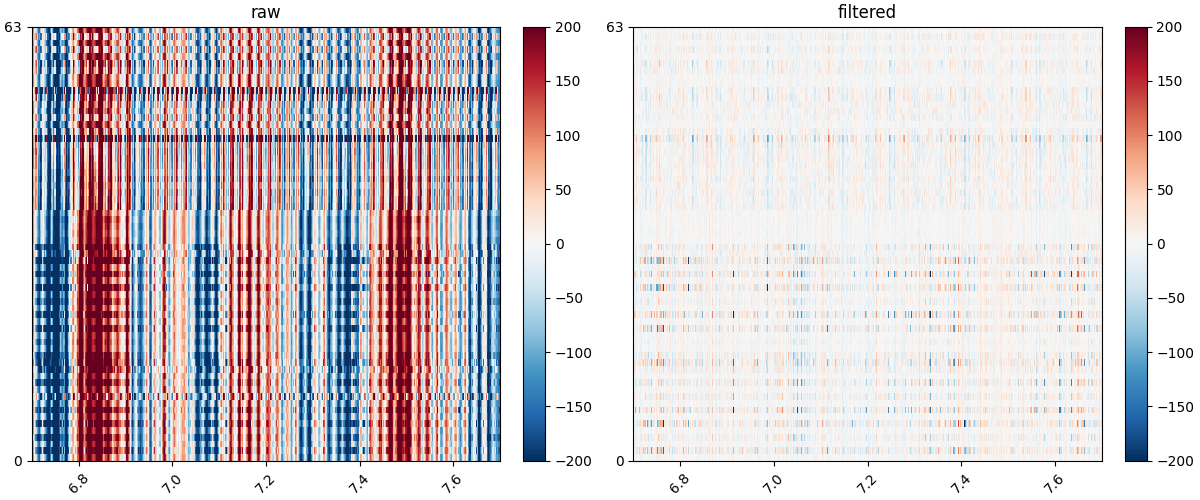

In [10]:
##Filtering
recording_bp = spre.bandpass_filter(
    recording, 
    # commonly used values to filter noise 
    # while not affecting spikes
    freq_min=300, 
    freq_max=6000
) 

plot_prepro(
    {"raw": recording, "filtered": recording_bp}, 
   time_range=(start_time, start_time+1)
)

In [17]:
print(recording_bp)
print(recording.get_property_keys())
print(recording.get_num_channels())

BandpassFilterRecording: 64 channels - 30.0kHz - 1 segments - 173,174,122 samples 
                         5,772.47s (1.60 hours) - int16 dtype - 20.64 GiB
['gain_to_uV', 'offset_to_uV', 'physical_unit', 'gain_to_physical_unit', 'offset_to_physical_unit', 'channel_name']
64


In [13]:
# detecting bad channels
bad_channel_ids, channel_labels = spre.detect_bad_channels(
    recording_bp, 
    dead_channel_threshold=-0.15,
    noisy_channel_threshold= 0.5,
    outside_channels_location="bottom",
    outside_channel_threshold=-0.25,
    n_neighbors=5
)
print(" labels:\n", channel_labels)

rec_clean = recording_bp.remove_channels(bad_channel_ids)

plot_prepro(
    {"filtered": recording_bp, 
    "bad channels removed": rec_clean},
    time_range=(start_time, start_time+1)
)

Exception: There are no channel locations

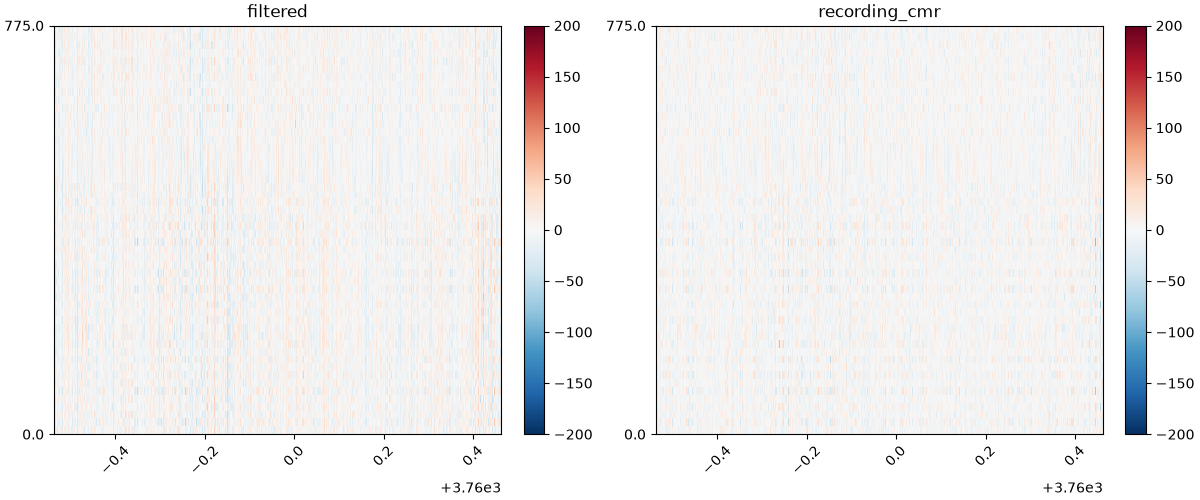

In [ ]:
#cmr
recording_cmr = spre.common_reference(
    rec_clean, 
    operator="median"
)

plot_prepro(
    {"filtered": rec_clean, 
    "recording_cmr": recording_cmr}, 
    time_range=(start_time, start_time+1)
)

In [ ]:
#save the prerprocessed recording


In [ ]:
ss.installed_sorters()

In [ ]:
#Sorting
import spikeinterface.sorters as ss
sorter_params = {"do_correction": False}

sorting_KS4 = ss.run_sorter(
    "kilosort4",
    recording_cmr,
    folder="results/sorter_KS4",
    remove_existing_folder=True,
    verbose=True,
    **sorter_params
)

write_binary (workers: 6 processes spawn):   0%|          | 0/554 [00:00<?, ?it/s]

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing preprocessing variables.
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: N samples: 16603655
kilosort.run_kilosort: N seconds: 553.4551666666666
kilosort.run_kilosort: N batches: 277
kilosort.run_kilosort: Preprocessing filters computed in 2.14s; total 2.14s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after preprocessing
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    99.30 %
kilosort.run_kilosort: Mem used:     91.50 %     |      14.36 GB
kilosort.run_kilosort: Mem avail:     1.33 / 15.69 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    N/A
kilosort.run_kilosort: GPU memory:   N/A
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
k

Skipping drift correction.


kilosort.spikedetect: Number of universal templates: 250
kilosort.spikedetect: Detecting spikes...
 11%|█         | 30/277 [06:21<52:19, 12.71s/it]  
kilosort.spikedetect: Error in spikedetect.run on batch 30
Traceback (most recent call last):
  File "c:\Users\phadn\anaconda3\envs\si-env\Lib\site-packages\kilosort\spikedetect.py", line 262, in run
    xy, imax, amp, adist = template_match(X, ops, iC, iC2, weigh, device=device)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\phadn\anaconda3\envs\si-env\Lib\site-packages\kilosort\spikedetect.py", line 151, in template_match
    A = torch.einsum('ijk, jklm-> iklm', weigh, B[iC,:, nb*t:nb*(t+1)])
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\phadn\anaconda3\envs\si-env\Lib\site-packages\torch\functional.py", line 372, in einsum
    return _VF.einsum(equation, operands)  # type: ignore[attr-defined]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInte

KeyboardInterrupt: 

In [ ]:
sorting_KS4 = si.load("results_2/sorter_KS4")
sorting_KS4

KiloSortSortingExtractor: 29 units - 1 segments - 30.0kHz

In [ ]:
sorter_params = {
    "apply_motion_correction": False,
}

sorting_SC2 = ss.run_sorter(
    "spykingcircus2",
    recording_cmr,
    folder="results_2/sorter_SC2",
    remove_existing_folder=True,
    verbose=True,
    **sorter_params
)

Preprocessing the recording (bandpass filtering + CMR + whitening)


noise_level (workers: 6 processes spawn):   0%|          | 0/20 [00:00<?, ?it/s]

Error running spykingcircus2


SpikeSortingError: Spike sorting error trace:
concurrent.futures.process._RemoteTraceback: 
'''
Traceback (most recent call last):
  File "c:\Users\phadn\anaconda3\envs\course-ephys\Lib\concurrent\futures\process.py", line 432, in wait_result_broken_or_wakeup
    result_item = result_reader.recv()
                  ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\phadn\anaconda3\envs\course-ephys\Lib\multiprocessing\connection.py", line 251, in recv
    return _ForkingPickler.loads(buf.getbuffer())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _reconstruct: First argument must be a sub-type of ndarray
'''

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\phadn\anaconda3\envs\course-ephys\Lib\site-packages\spikeinterface\sorters\basesorter.py", line 266, in run_from_folder
    SorterClass._run_from_folder(sorter_output_folder, sorter_params, verbose)
  File "c:\Users\phadn\anaconda3\envs\course-ephys\Lib\site-p